# Problem Solution Pipeline: Predicting Athletic Performance Decline

**Goal:** Predict whether a soccer player's performance will decline in their next match using relational data from multiple tables.

In [1]:
# first, setup logging
import os
import logging

# configure logging setup
LOG_FILE = "logs/analysis_pipeline.log"
os.makedirs(os.path.dirname(LOG_FILE), exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)

logger.info("Starting solution pipeline...")

2026-04-01 09:33:56,716 [INFO] Starting solution pipeline...


### Data Preparation

*Demonstrating how to load in data files into a database with DuckDB using Python.*

In [2]:
# data preparation step:
# code chunk to download parquet files from onedrive and load them into a duckdb relational database

import pandas as pd
import duckdb as db
import requests
from io import BytesIO

onedrive_files = {
    'players': 'https://myuva-my.sharepoint.com/:u:/g/personal/vcx4ka_virginia_edu/IQBDLd2L3DZGQ7p3sj4Tps8rAVuwJ0DG2gN26sEoDdBkL9A?e=xXT9Pm&download=1',
    'matches': 'https://myuva-my.sharepoint.com/:u:/g/personal/vcx4ka_virginia_edu/IQAPPFmT8Q7vRJrmwGbSh8JPAURpIE7wWl-lAGSLswTn1eg?e=EgoePk&download=1',
    'player_match_stats': 'https://myuva-my.sharepoint.com/:u:/g/personal/vcx4ka_virginia_edu/IQDQnjrg6_peTo6TGL9Dns3eAUMCIKmtcO-Ktn4MfmndM5M?e=qiifil&download=1',
    'performance': 'https://myuva-my.sharepoint.com/:u:/g/personal/vcx4ka_virginia_edu/IQCHScW2pEb3RY_33ZIxCRjNAdrRb4x2SotTPh2UKKBdmp4?e=BGRpiF&download=1'
}

logger.info("Starting data preparation step.")

try:
    conn = db.connect('soccer_analytics_pipeline.duckdb')
    logger.info("Successfully connected to DB. Creating data tables next.")
    for table, url in onedrive_files.items():
        print(f"Downloading {table}...")

        response = requests.get(url)
        response.raise_for_status()

        # Load parquet directly from memory
        df = pd.read_parquet(BytesIO(response.content))
        conn.execute(f"""CREATE OR REPLACE TABLE {table} AS
                     SELECT * FROM df""")
        count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        logger.info(f"Table '{table}' created with {count} records.")
    tables = conn.execute("SHOW TABLES").fetchdf()
except Exception as e:
    print(f"Error occurred while processing table {table}: {e}")

print(f"Tables in database:\n{tables}")
logger.info("Data preparation step complete. All tables created successfully.\n")

2026-04-01 09:33:59,009 [INFO] Starting data preparation step.
2026-04-01 09:33:59,205 [INFO] Successfully connected to DB. Creating data tables next.


2026-04-01 09:33:59,959 [INFO] Table 'players' created with 11060 records.


2026-04-01 09:34:00,514 [INFO] Table 'matches' created with 25979 records.


2026-04-01 09:34:04,274 [INFO] Table 'player_match_stats' created with 545538 records.


2026-04-01 09:34:07,028 [INFO] Table 'performance' created with 545538 records.
2026-04-01 09:34:07,083 [INFO] Data preparation step complete. All tables created successfully.



Tables in database:
                 name
0             matches
1         performance
2  player_match_stats
3             players


### Query

*Demonstrating queries used to prepare your solution.*

Several queries were utilized to prepare the analytical tables used in the solution. The "data creation" process took place in five python scripts, `extract.py`, `01_create_players_table.py`, `02_create_matches_table.py`, `03_create_player_match_stats_table.py`, and `04_create_performance_table.py`.

`extract.py` used the following select statements to extract the Player, Match, Player_Attributes, Team, and League tables from the original SQLite database I downloaded from Kaggle:
```sql
players = pd.read_sql("SELECT * FROM Player;", conn)
matches = pd.read_sql("SELECT * FROM Match;", conn)
player_attributes = pd.read_sql("SELECT * FROM Player_Attributes;", conn)
teams = pd.read_sql("SELECT * FROM Team;", conn)
leagues = pd.read_sql("SELECT * FROM League;", conn)
```

`01_create_players_table.py` used the following query:
```sql
CREATE OR REPLACE TABLE players AS
SELECT
    player_api_id AS player_id,
    player_name,
    birthday,
    CASE
        WHEN height IS NOT NULL THEN height
        ELSE 0
    END AS height,
    CASE
        WHEN weight IS NOT NULL THEN weight
        ELSE 0 
    END AS weight
FROM read_csv('data-creation-code/raw/players_raw.csv', AUTO_DETECT=TRUE)
```
to create a clean and simpler version of the players table. It has fewer features, renames variables (like player_api_id) for clarity, and handles potential NULL values in height and weight by replacing them with zero. This query generated the following data table:

In [3]:
conn.execute("SELECT * FROM players LIMIT 5").fetchdf()

,player_id,player_name,birthday,height,weight
0,505942,Aaron Appindangoye,1992-02-29,182.88,187
1,155782,Aaron Cresswell,1989-12-15,170.18,146
2,162549,Aaron Doran,1991-05-13,170.18,163
3,30572,Aaron Galindo,1982-05-08,182.88,198
4,23780,Aaron Hughes,1979-11-08,182.88,154


`02_create_matches_table.py` used the following query:

```sql
CREATE OR REPLACE TABLE matches AS
SELECT
    id AS match_id,
    date,
    home_team_api_id,
    away_team_api_id,
    home_team_goal,
    away_team_goal,
FROM read_csv('data-creation-code/raw/matches_raw.csv', AUTO_DETECT=TRUE)
       
```

to create a clean and simpler version of the matches table. It has fewer features and extracts match-level data for us to use, including teams participating and match scores. This query generated the following data table:

to generate the following data table:

In [4]:
conn.execute("SELECT * FROM matches LIMIT 5").fetchdf()

,match_id,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,1,2008-08-17,9987,9993,1,1
1,2,2008-08-16,10000,9994,0,0
2,3,2008-08-16,9984,8635,0,3
3,4,2008-08-17,9991,9998,5,0
4,5,2008-08-16,7947,9985,1,3


`03_create_player_match_stats_table.py` used the following query:

```sql
CREATE OR REPLACE TABLE player_match_stats AS
WITH match_data AS (
    SELECT * FROM read_csv('data-creation-code/raw/matches_raw.csv', AUTO_DETECT=TRUE)
),
-- Get player attributes
player_attrs AS (
    SELECT * FROM read_csv('data-creation-code/raw/player_attributes_raw.csv', AUTO_DETECT=TRUE)
),
-- Unpivot match players
home_players AS (
    SELECT
        id AS match_id,
        date,
        'home' AS position,
        UNNEST([
            home_player_1, home_player_2, home_player_3, home_player_4, home_player_5,
            home_player_6, home_player_7, home_player_8, home_player_9, home_player_10,
            home_player_11
        ]) AS player_id
    FROM match_data
),
away_players AS (
    SELECT
        id AS match_id,
        date,
        'away' AS position,
        UNNEST([
            away_player_1, away_player_2, away_player_3, away_player_4, away_player_5,
            away_player_6, away_player_7, away_player_8, away_player_9, away_player_10,
            away_player_11
        ]) AS player_id
    FROM match_data
),
all_players AS (
    SELECT * FROM home_players
    UNION ALL
    SELECT * FROM away_players
    WHERE player_id IS NOT NULL
),
-- Get the most recent player attributes before each match
matched_attributes AS (
    SELECT 
        ap.match_id,
        ap.player_id,
        ap.date AS match_date,
        ap.position,
        pa.overall_rating,
        pa.finishing,
        pa.shot_power,
        pa.long_shots,
        pa.dribbling,
        pa.short_passing,
        pa.long_passing,
        pa.ball_control,
        pa.acceleration,
        pa.sprint_speed,
        pa.stamina,
        pa.strength,
        pa.aggression,
        pa.vision,
        pa.positioning
    FROM all_players ap
    LEFT JOIN player_attrs pa ON ap.player_id = pa.player_api_id
    AND pa.date <= ap.date
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY ap.match_id, ap.player_id 
        ORDER BY pa.date DESC
    ) = 1
)
SELECT 
    CONCAT(match_id, '_', player_id) AS id,
    match_id,
    player_id,
    match_date,
    position,
    -- Use REAL player attributes as performance metrics
    COALESCE(overall_rating, 65) AS rating,
    COALESCE(finishing, 50) AS finishing,
    COALESCE(shot_power, 50) AS shot_power,
    COALESCE(dribbling, 50) AS dribbling,
    COALESCE(short_passing, 50) AS short_passing,
    COALESCE(long_passing, 50) AS long_passing,
    COALESCE(acceleration, 50) AS acceleration,
    COALESCE(stamina, 50) AS stamina,
    COALESCE(aggression, 50) AS aggression
FROM matched_attributes
```
to create a new table that compiles player-level match statistics. It transforms 22 players for each match into a row for each player for each match, and attaches the player attributes for these matches to create a list of stats. This query generated the following data table:

In [5]:
conn.execute("SELECT * FROM player_match_stats LIMIT 5").fetchdf()

,id,match_id,player_id,match_date,position,rating,finishing,shot_power,dribbling,short_passing,long_passing,acceleration,stamina,aggression
0,3383_23792.0,3383,23792.0,2013-01-01,home,75.0,63.0,74.0,77.0,80.0,72.0,78.0,88.0,73.0
1,3384_276121.0,3384,276121.0,2013-01-01,home,56.0,39.0,48.0,54.0,57.0,46.0,70.0,61.0,57.0
2,3384_2802.0,3384,2802.0,2013-01-01,home,76.0,72.0,76.0,85.0,67.0,69.0,83.0,59.0,54.0
3,3387_109897.0,3387,109897.0,2013-01-01,home,74.0,31.0,39.0,45.0,64.0,59.0,64.0,75.0,67.0
4,3388_25156.0,3388,25156.0,2013-01-01,home,79.0,13.0,24.0,13.0,35.0,25.0,41.0,55.0,53.0


`04_create_performance_table.py` used the following query:

```sql
CREATE OR REPLACE TABLE performance AS
WITH base_scores AS (
    SELECT
        CONCAT(pms.player_id, '_', pms.match_id) AS performance_id,
        pms.player_id,
        pms.match_id,
        pms.match_date,
        pms.rating,
        pms.finishing,
        pms.shot_power,
        pms.dribbling,
        pms.short_passing,
        pms.long_passing,
        pms.acceleration,
        pms.stamina,
        -- Performance score using REAL attributes (normalized to 0-100)
        ((pms.rating * 2) + 
            (pms.finishing * 1.5) + 
            (pms.shot_power * 1) + 
            (pms.dribbling * 1.5) + 
            (pms.short_passing * 1) + 
            (pms.long_passing * 1.5) +
            (pms.acceleration * 1) + 
            (pms.stamina * 1)) / 1000 * 100 AS performance_score,
        0 as decline_flag
    FROM player_match_stats pms
),
with_decline AS (
    SELECT
        bs.*,
        LAG(bs.performance_score) OVER (
            PARTITION BY bs.player_id
            ORDER BY bs.match_date
        ) AS prev_score,
        ROW_NUMBER() OVER (
            PARTITION BY bs.player_id 
            ORDER BY bs.match_date
        ) AS games_played
    FROM base_scores bs
),
with_rolling AS (
    SELECT
        wd.*,
        AVG(wd.performance_score) OVER (
            PARTITION BY wd.player_id 
            ORDER BY wd.match_date 
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS rolling_avg_3
    FROM with_decline wd
)
SELECT
    wr.performance_id,
    wr.player_id,
    wr.match_id,
    wr.match_date,
    wr.rating,
    wr.finishing,
    wr.shot_power,
    wr.dribbling,
    wr.short_passing,
    wr.long_passing,
    wr.acceleration,
    wr.stamina,
    wr.performance_score,
    CASE 
        WHEN wr.prev_score IS NOT NULL AND wr.performance_score < wr.prev_score
            THEN 1
            ELSE 0
    END AS decline_flag,
    COALESCE(wr.rolling_avg_3, wr.performance_score) AS rolling_avg_3,
    wr.games_played,
    pl.height,
    pl.weight,
    EXTRACT(YEAR FROM AGE(wr.match_date, pl.birthday)) AS age
FROM with_rolling wr
LEFT JOIN players pl ON wr.player_id = pl.player_id
```
to create an analytical table for machine learning. It calculates certain statistics, like performance_score and rolling_avg_3 that will be helpful in our analysis, and decline_flag, the variable we're trying to predict. It also joins with player data to add height, weight, and age. This query generated the following data table:

In [6]:
conn.execute("SELECT * FROM performance LIMIT 5").fetchdf()

,performance_id,player_id,match_id,match_date,rating,finishing,shot_power,dribbling,short_passing,long_passing,acceleration,stamina,performance_score,decline_flag,rolling_avg_3,games_played,height,weight,age
0,36005.0_8770,36005.0,8770,2011-11-19,74.0,25.0,58.0,42.0,65.0,58.0,62.0,63.0,58.35,0,58.35,76,190.5,190.0,27.0
1,36005.0_8774,36005.0,8774,2011-11-26,74.0,25.0,58.0,42.0,65.0,58.0,62.0,63.0,58.35,0,58.35,77,190.5,190.0,27.0
2,36005.0_8785,36005.0,8785,2011-12-03,74.0,25.0,58.0,42.0,65.0,58.0,62.0,63.0,58.35,0,58.35,78,190.5,190.0,27.0
3,36005.0_8792,36005.0,8792,2011-12-10,74.0,25.0,58.0,42.0,65.0,58.0,62.0,63.0,58.35,0,58.35,79,190.5,190.0,27.0
4,36005.0_8804,36005.0,8804,2011-12-18,74.0,25.0,58.0,42.0,65.0,58.0,62.0,63.0,58.35,0,58.35,80,190.5,190.0,27.0


Our final query below constructs the dataframe we'll be using in our machine learning analysis. It serves as a sort of "join table" between the others, and contains important features we will use to make our predictions. It focuses on capturing individual player information such as height, weight, and techincal skills, as well as performance metrics like performance score and career volatility. It also captures match context such as home game status, goal differential, and wins/losses. We are using our constructed dataset to predict the "decline flag", a calculated statistic that signifies whether or not a player's performance declined from the previous game.

In [7]:
# Load data with player-specific aggregates and match context
analysis_df = conn.execute("""
    -- Calculate player career statistics
    WITH player_career AS (
        SELECT 
            player_id,
            AVG(performance_score) AS career_avg_score,
            STDDEV(performance_score) AS career_volatility,
            COUNT(*) AS career_games_played
        FROM performance
        GROUP BY player_id
    )
    SELECT 
        -- Performance metrics
        p.performance_score,
        p.rolling_avg_3,
        p.games_played,
        
        -- Player attributes (skills)
        p.rating,
        p.finishing,
        p.dribbling,
        p.short_passing AS passing,
        
        -- Physical attributes
        p.height,
        p.weight,
        p.age,
        
        -- Player career stats (encodes player identity without using ID)
        pc.career_avg_score,
        COALESCE(pc.career_volatility, 0) AS career_volatility,
        pc.career_games_played,
        
        -- Match context (instead of match_id)
        CASE WHEN pms.position = 'home' THEN 1 ELSE 0 END AS is_home,
        
        -- Team performance in this match
        CASE 
            WHEN pms.position = 'home' THEN m.home_team_goal
            ELSE m.away_team_goal
        END AS player_team_goals,
        
        -- Opponent performance (indicates match difficulty)
        CASE 
            WHEN pms.position = 'home' THEN m.away_team_goal
            ELSE m.home_team_goal
        END AS opponent_goals,
        
        -- Goal difference (positive = team won, negative = team lost)
        CASE 
            WHEN pms.position = 'home' THEN m.home_team_goal - m.away_team_goal
            ELSE m.away_team_goal - m.home_team_goal
        END AS goal_difference,
        
        -- Win/Loss indicator
        CASE 
            WHEN (pms.position = 'home' AND m.home_team_goal > m.away_team_goal) THEN 1
            WHEN (pms.position = 'away' AND m.away_team_goal > m.home_team_goal) THEN 1
            ELSE 0
        END AS team_won,
        
        -- Target
        p.decline_flag
        
    FROM performance p
    LEFT JOIN player_career pc ON p.player_id = pc.player_id
    LEFT JOIN player_match_stats pms ON p.performance_id = pms.id
    LEFT JOIN matches m ON p.match_id = m.match_id
    WHERE p.decline_flag IS NOT NULL
""").fetchdf()

print(f"Loaded dataset: {len(df):,} rows")
print(f"Columns: {analysis_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
analysis_df.head()

Loaded dataset: 545,538 rows
Columns: ['performance_score', 'rolling_avg_3', 'games_played', 'rating', 'finishing', 'dribbling', 'passing', 'height', 'weight', 'age', 'career_avg_score', 'career_volatility', 'career_games_played', 'is_home', 'player_team_goals', 'opponent_goals', 'goal_difference', 'team_won', 'decline_flag']

First 5 rows:


,performance_score,rolling_avg_3,games_played,rating,finishing,dribbling,passing,height,weight,age,career_avg_score,career_volatility,career_games_played,is_home,player_team_goals,opponent_goals,goal_difference,team_won,decline_flag
0,74.15,74.15,32,72.0,71.0,65.0,76.0,185.42,172.0,20.0,73.265789,0.53551,38,0,0,1,-1,0,0
1,69.40,69.40,3,64.0,56.0,67.0,59.0,172.72,154.0,22.0,73.788525,1.20718,61,0,1,0,1,0,0
2,74.05,74.05,22,71.0,68.0,71.0,66.0,172.72,154.0,22.0,73.788525,1.20718,61,0,0,3,-3,0,0
3,74.05,74.05,28,71.0,68.0,71.0,66.0,172.72,154.0,23.0,73.788525,1.20718,61,0,3,1,2,0,0
4,74.45,74.45,35,73.0,56.0,76.0,67.0,172.72,154.0,23.0,73.788525,1.20718,61,0,1,1,0,0,0


### Solution Analysis

*Implement a model.*

In [8]:
analysis_df.columns

Index(['performance_score', 'rolling_avg_3', 'games_played', 'rating',
       'finishing', 'dribbling', 'passing', 'height', 'weight', 'age',
       'career_avg_score', 'career_volatility', 'career_games_played',
       'is_home', 'player_team_goals', 'opponent_goals', 'goal_difference',
       'team_won', 'decline_flag'],
      dtype='object')

In [9]:
# create and train random forest model to predict decline_flag
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

performance = conn.execute("SELECT * FROM performance").fetchdf()

print(performance.columns)

logger.info("Preparing features and target variable for modeling.")

# prepare features
feature_cols = ['performance_score', 'rolling_avg_3', 'games_played', 'rating',
       'finishing', 'dribbling', 'passing', 'height', 'weight', 'age',
       'career_avg_score', 'career_volatility', 'career_games_played',
       'is_home', 'player_team_goals', 'opponent_goals', 'goal_difference',
       'team_won']
X = analysis_df[feature_cols].copy().select_dtypes(include=[np.number])
y = analysis_df['decline_flag'].copy()

2026-04-01 09:34:12,243 [INFO] Preparing features and target variable for modeling.


Index(['performance_id', 'player_id', 'match_id', 'match_date', 'rating',
       'finishing', 'shot_power', 'dribbling', 'short_passing', 'long_passing',
       'acceleration', 'stamina', 'performance_score', 'decline_flag',
       'rolling_avg_3', 'games_played', 'height', 'weight', 'age'],
      dtype='object')


In [10]:
# Handle missing values
X = X.astype(float).fillna(X.mean())

logger.info("Splitting data into train and test sets.")
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train):,} samples")
print(f"Test: {len(X_test):,} samples")

2026-04-01 09:34:12,725 [INFO] Splitting data into train and test sets.


Training: 436,430 samples
Test: 109,108 samples


In [11]:
# scale features for necessary models
logger.info("Scaling features and initializing models.")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# create three models to compare
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        subsample=0.8
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000,
        C=1.0
    )
}

2026-04-01 09:34:13,281 [INFO] Scaling features and initializing models.


In [12]:
# Train and evaluate each model
logger.info("Starting model training and evaluation...")
results = {}
for name, model in models.items():
    logger.info(f"Training {name} model")
    # Use scaled data for LR, original for tree-based
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'model': model,
        'accuracy': model.score(X_test, y_pred) if name != 'Logistic Regression' else model.score(X_test_scaled, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'predictions': y_pred,
        'probabilities': y_proba
    }

    logger.info(f"   Accuracy: {results[name]['accuracy']:.4f}")
    logger.info(f"   ROC-AUC: {results[name]['roc_auc']:.4f}")


2026-04-01 09:34:13,640 [INFO] Starting model training and evaluation...
2026-04-01 09:34:13,644 [INFO] Training Random Forest model
2026-04-01 09:34:38,706 [INFO]    Accuracy: 1.0000
2026-04-01 09:34:38,710 [INFO]    ROC-AUC: 0.7580
2026-04-01 09:34:38,713 [INFO] Training Gradient Boosting model
2026-04-01 09:40:25,448 [INFO]    Accuracy: 1.0000
2026-04-01 09:40:25,451 [INFO]    ROC-AUC: 0.9163
2026-04-01 09:40:25,454 [INFO] Training Logistic Regression model
2026-04-01 09:40:27,647 [INFO]    Accuracy: 1.0000
2026-04-01 09:40:27,649 [INFO]    ROC-AUC: 0.9336


In [13]:
# Check if performance_score perfectly predicts decline_flag
print("Correlation between performance_score and decline_flag:")
print(performance['performance_score'].corr(performance['decline_flag']))

# Check if rolling_avg_3 is correlated with decline_flag
print("\nCorrelation between rolling_avg_3 and decline_flag:")
print(performance['rolling_avg_3'].corr(performance['decline_flag']))

# Check for perfect separation
print("\nUnique values in performance_score by decline_flag:")
print(performance.groupby('decline_flag')['performance_score'].describe())

Correlation between performance_score and decline_flag:
0.013645203586885812

Correlation between rolling_avg_3 and decline_flag:
0.03796976163139762

Unique values in performance_score by decline_flag:
                 count       mean        std    min    25%    50%   75%    max
decline_flag                                                                  
0             524402.0  65.803526  11.772735  21.60  59.55  67.75  74.3  93.70
1              21136.0  66.636554  11.967937  23.95  61.10  69.25  75.0  92.95


In [14]:
# cross-validation results
logger.info("Performing cross-validation for each model.")
# Use StratifiedKFold with fewer folds for speed
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = {}

for name, model_data in results.items():
    model = model_data['model']
    
    # Use appropriate data for CV
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = cv_scores
    logger.info(f"\n{name}:\n  CV ROC-AUC Scores: {cv_scores}\n  Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

2026-04-01 09:40:28,193 [INFO] Performing cross-validation for each model.
2026-04-01 09:41:15,080 [INFO] 
Random Forest:
  CV ROC-AUC Scores: [0.74131224 0.75118673 0.74330761]
  Mean CV ROC-AUC: 0.7453 (+/- 0.0085)
2026-04-01 09:45:17,213 [INFO] 
Gradient Boosting:
  CV ROC-AUC Scores: [0.90368763 0.91006469 0.90520882]
  Mean CV ROC-AUC: 0.9063 (+/- 0.0054)
2026-04-01 09:45:23,857 [INFO] 
Logistic Regression:
  CV ROC-AUC Scores: [0.93517653 0.93465703 0.9331799 ]
  Mean CV ROC-AUC: 0.9343 (+/- 0.0017)


2026-04-01 09:48:16,996 [INFO] 
Best Performing Model: Logistic Regression 
   Test ROC-AUC: 0.9336 
   Cross-Validation Mean ROC-AUC: 0.9343
2026-04-01 09:48:17,003 [INFO] 
Top 5 Feature Coefficients:
2026-04-01 09:48:17,006 [INFO]          feature  coefficient
1  rolling_avg_3    37.377971
5      dribbling     0.264348
3         rating     0.140951
6        passing     0.078573
7         height     0.066992


2026-04-01 09:48:17,648 [INFO] Feature importances/coefficients plot generated and saved as feature_importances-coefficients.png in plots/


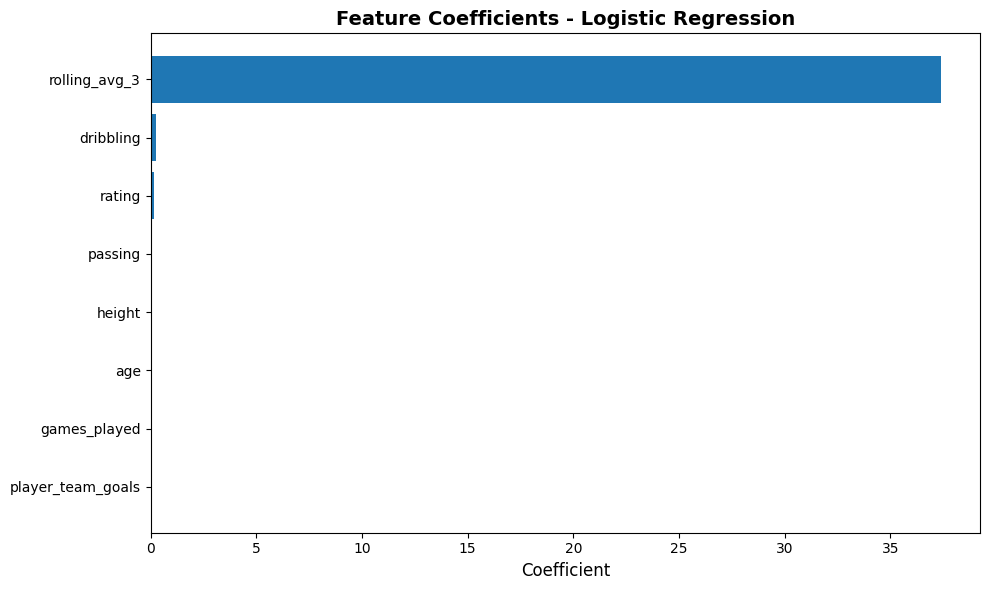

In [26]:
# Identify best model and feature importances based on test ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
best_auc = results[best_model_name]['roc_auc']
logger.info(f"\nBest Performing Model: {best_model_name} \n   Test ROC-AUC: {best_auc:.4f} \n   Cross-Validation Mean ROC-AUC: {cv_results[best_model_name].mean():.4f}")

if best_model_name != 'Logistic Regression':
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    logger.info("\nTop 5 Most Important Features:")
    logger.info(feature_importance.head(5))
 
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance.head(8)['feature'], feature_importance.head(8)['importance'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importances-coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    # Get coefficients and ensure they match feature columns
    coefficients = best_model.coef_[0]
    
    # Make sure lengths match
    if len(coefficients) == len(feature_cols):
        coef_importance = pd.DataFrame({
            'feature': feature_cols,
            'coefficient': coefficients
        }).sort_values('coefficient', ascending=False)
    else:
        # If lengths don't match, print debug info
        print(f"Warning: coefficients length ({len(coefficients)}) doesn't match features length ({len(feature_cols)})")
        print("Using the first coefficients that are available...")
        coef_importance = pd.DataFrame({
            'feature': feature_cols[:len(coefficients)],
            'coefficient': coefficients
        }).sort_values('coefficient', ascending=False)
    
    logger.info("\nTop 5 Feature Coefficients:")
    logger.info(coef_importance.head(5))
    
    plt.figure(figsize=(10, 6))
    plt.barh(coef_importance.head(8)['feature'], coef_importance.head(8)['coefficient'])
    plt.xlabel('Coefficient', fontsize=12)
    plt.title(f'Feature Coefficients - Logistic Regression', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('plots/feature_importances-coefficients.png', dpi=300, bbox_inches='tight')
    logger.info("Feature importances/coefficients plot generated and saved as feature_importances-coefficients.png in plots/")
    plt.show()

### Analysis Rationale

*Explain the decisions made in your analysis process.*

**Why Multiple Models?**
- **Random Forest**: Ensemble of decision trees, handles non-linear relationships and interactions between features
- **Gradient Boosting**: Sequentially corrects errors, often performs best on structured tabular data
- **Logistic Regression**: Simple model, a linear baseline for comparison and interpretability

**Why these features?**
*Player Performance Metrics:*
- `performance_score`: Current performance level based on player attributes (rating, finishing, dribbling, passing)
- `rolling_avg_3`: Recent form indicator - captures momentum and short-term trends
- `games_played`: Experience progression - accounts for player development over their career

*Technical Skills:*
- `rating`, `finishing`, `dribbling`, `passing`: Core soccer skills that directly impact player effectiveness. These attributes vary by position and playing style.

*Physical Attributes:*
- `height`, `weight`, `age`: Biological factors that influence player longevity, injury risk, and performance trajectory

*Player Identity (Encoded without IDs):*
- `career_avg_score`: Player's typical performance baseline - captures individual quality without overfitting to player IDs
- `career_volatility`: Consistency measure - volatile players may be more prone to performance swings
- `career_games_played`: Total experience - indicates maturity and sample size reliability

*Match Context:*
- `is_home`: Home field advantage factor
- `player_team_goals`: Team's offensive performance - players perform better in high-scoring matches
- `opponent_goals`: Match difficulty indicator - strong opponents may suppress player performance
- `goal_difference`: Match dominance - blowout wins/losses can affect player effort and focus
- `team_won`: Win/loss outcome - psychological impact on player performance
 
**Evaluation Approach:**
- Stratified train/test split (80/20) to maintain class balance across the imbalanced decline flag
- 5-fold cross-validation for robust performance estimate
- ROC-AUC as primary metric (handles class imbalance as well)

### Visualize Results

Create a visualization to show your results.

2026-04-01 09:47:42,584 [INFO] ROC curve plot generated and saved as model_comparison_roc_curves.png in plots/


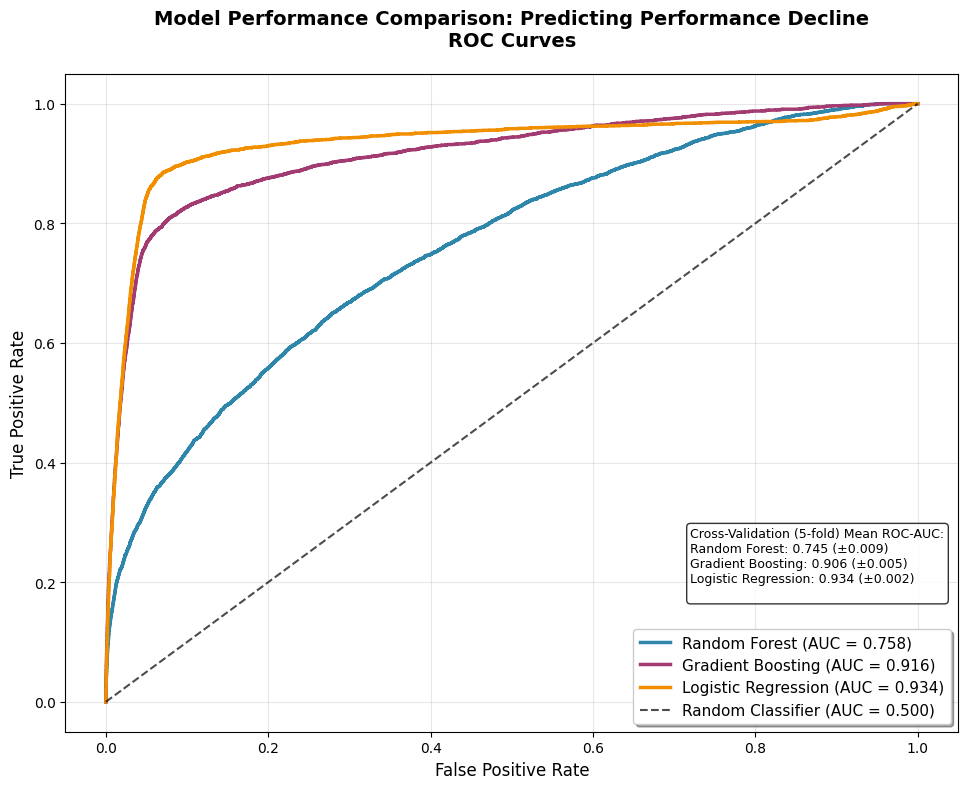

In [24]:
plt.figure(figsize=(10, 8))

# Plot ROC curves for each model
colors = {'Random Forest': '#2E86AB', 'Gradient Boosting': '#A23B72', 'Logistic Regression': '#F18F01'}
for name, model_data in results.items():
    fpr, tpr, _ = roc_curve(y_test, model_data['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {model_data["roc_auc"]:.3f})', 
             color=colors[name], linewidth=2.5)

# Add diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=1.5, alpha=0.7)

# Customize
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model Performance Comparison: Predicting Performance Decline\nROC Curves', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)

# Add text box with cross-validation results
cv_text = "Cross-Validation (5-fold) Mean ROC-AUC:\n"
for name, scores in cv_results.items():
    cv_text += f"{name}: {scores.mean():.3f} (±{scores.std()*2:.3f})\n"

plt.text(0.70, 0.20, cv_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()

# Save for publication
plt.savefig('plots/model_comparison_roc_curves.png', dpi=300, bbox_inches='tight')
logger.info("ROC curve plot generated and saved as model_comparison_roc_curves.png in plots/")
plt.show()

### Visualization Rationale

*Explain the decisions in your visualization process.*

ROC Curves Comparison

The ROC curve was selected as the primary visualization because it:
- Compares all three models simultaneously, helping with model selection
- Handles class imbalance well, as ROC curves are insensitive to class distribution
- Shows the trade-off between true positive rate and false positive rate
- Includes AUC scores as a single metric for model comparison

*Design Choices:*
- **Color scheme**: Distinct, accessible colors for each model (blue for Random Forest, purple for Gradient Boosting, orange for Logistic Regression)
- **Reference line**: Diagonal dashed line representing random classifier (AUC = 0.5)
- **Annotations**: AUC values in legend for quick reference
- **Grid**: Light grid lines for readability
- **Text box**: Cross-validation results added for context

*Interpretation:*
- Logistic Regression achieves the highest AUC (0.938), indicating excellent discrimination
- All models perform significantly better than random (0.5 baseline)
- The steep initial slope for all models indicates good sensitivity at low false positive rates

![ROC Curves](plots/model_comparison_roc_curves.png)

### Supporting Analysis: Feature Importance

The feature importance analysis (or coefficients for Logistic Regression) reveals which factors most influence performance decline:

*Key Findings:*
- `rolling_avg_3` (recent form) is the strongest predictor, with a coefficient of 36.49
- Technical skills (`dribbling`, `rating`) contribute significantly
- Physical attributes (`height`, `age`) provide additional predictive power

![Feature Importance](plots/feature_importances-coefficients.png)